<a href="https://colab.research.google.com/github/Srideep-Kundu/MLProjects/blob/main/us_accidents_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# US Accidents Exploratory Data Analysis
 * TODO - talk about EDA
 * TODO - talk about the dataset (source, what it contains, how it will be useful)
   - Kaggle
   - information about accidents
   - can use useful to prevent accidents
   - this does not contain data for new york


## Download the data

In [1]:
!pip install opendatasets --upgrade

In [2]:
import opendatasets as od

download_url = 'https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents'

od.download(download_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: srideepkundu
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents


100%|██████████| 653M/653M [00:00<00:00, 1.18GB/s]


In [3]:
data_filename = '/content/us-accidents/US_Accidents_March23.csv'

## Data Preparation and Cleaning

- Load the file using Pandas
- Look at some info about the data and the columns
- Fix any missing or incorrect values

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv(data_filename)

In [6]:
df

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.010,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.010,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.010,...,False,False,False,False,True,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,A-7777757,Source1,2,2019-08-23 18:03:25,2019-08-23 18:32:01,34.002480,-117.379360,33.99888,-117.37094,0.543,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,A-7777758,Source1,2,2019-08-23 19:11:30,2019-08-23 19:38:23,32.766960,-117.148060,32.76555,-117.15363,0.338,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,A-7777759,Source1,2,2019-08-23 19:00:21,2019-08-23 19:28:49,33.775450,-117.847790,33.77740,-117.85727,0.561,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,A-7777760,Source1,2,2019-08-23 19:00:21,2019-08-23 19:29:42,33.992460,-118.403020,33.98311,-118.39565,0.772,...,False,False,False,False,False,False,Day,Day,Day,Day


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

In [8]:
df.describe()

,Severity,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
count,7.728394e+06,7.728394e+06,7.728394e+06,4.325632e+06,4.325632e+06,7.728394e+06,7.564541e+06,5.729375e+06,7.554250e+06,7.587715e+06,7.551296e+06,7.157161e+06,5.524808e+06
mean,2.212384e+00,3.620119e+01,-9.470255e+01,3.626183e+01,-9.572557e+01,5.618423e-01,6.166329e+01,5.825105e+01,6.483104e+01,2.953899e+01,9.090376e+00,7.685490e+00,8.407210e-03
std,4.875313e-01,5.076079e+00,1.739176e+01,5.272905e+00,1.810793e+01,1.776811e+00,1.901365e+01,2.238983e+01,2.282097e+01,1.006190e+00,2.688316e+00,5.424983e+00,1.102246e-01
min,1.000000e+00,2.455480e+01,-1.246238e+02,2.456601e+01,-1.245457e+02,0.000000e+00,-8.900000e+01,-8.900000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,3.339963e+01,-1.172194e+02,3.346207e+01,-1.177543e+02,0.000000e+00,4.900000e+01,4.300000e+01,4.800000e+01,2.937000e+01,1.000000e+01,4.600000e+00,0.000000e+00
50%,2.000000e+00,3.582397e+01,-8.776662e+01,3.618349e+01,-8.802789e+01,3.000000e-02,6.400000e+01,6.200000e+01,6.700000e+01,2.986000e+01,1.000000e+01,7.000000e+00,0.000000e+00
75%,2.000000e+00,4.008496e+01,-8.035368e+01,4.017892e+01,-8.024709e+01,4.640000e-01,7.600000e+01,7.500000e+01,8.400000e+01,3.003000e+01,1.000000e+01,1.040000e+01,0.000000e+00
max,4.000000e+00,4.900220e+01,-6.711317e+01,4.907500e+01,-6.710924e+01,4.417500e+02,2.070000e+02,2.070000e+02,1.000000e+02,5.863000e+01,1.400000e+02,1.087000e+03,3.647000e+01


In [9]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

newdf = df.select_dtypes(include=numerics)
len(newdf.columns)

13

Percentage of missing values per column

In [10]:
missing_percentages = df.isnull().sum().sort_values(ascending=False) / len(df)
missing_percentages

,0
End_Lng,4.402935e-01
End_Lat,4.402935e-01
Precipitation(in),2.851286e-01
Wind_Chill(F),2.586590e-01
Wind_Speed(mph),7.391355e-02
Visibility(mi),2.291524e-02
Wind_Direction,2.267043e-02
Humidity(%),2.253301e-02
Weather_Condition,2.244438e-02
Temperature(F),2.120143e-02


In [11]:
type(missing_percentages)

pandas.core.series.Series

<Axes: >

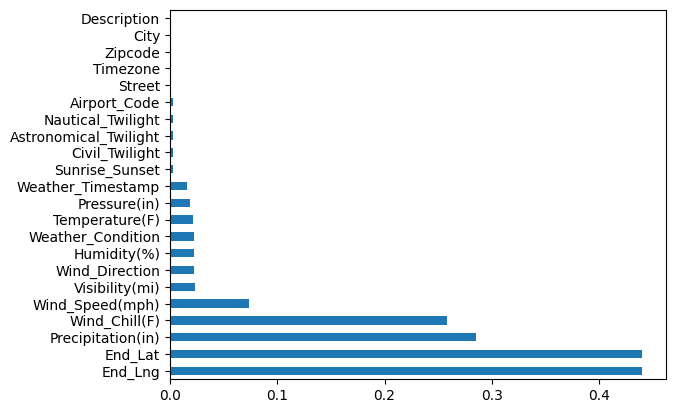

In [12]:
missing_percentages[missing_percentages != 0].plot(kind='barh')

Remove columns that you don't want to use

## Exploratory Analysis and visualisation

columns we'll analyze:

1. City
2. Start Time
3. Start_lat, start_lng
4. Temperature
5. Weather condition

In [13]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

###Cities

In [14]:
cities = df.City.unique()
len(cities)

13679

In [15]:
cities_by_accident = df.City.value_counts()
cities_by_accident

,count
City,
Miami,186917
Houston,169609
Los Angeles,156491
Charlotte,138652
Dallas,130939
...,...
Rapid River,1
Cat Spring,1
Glenwood City,1


In [16]:
cities_by_accident[:20]

,count
City,
Miami,186917
Houston,169609
Los Angeles,156491
Charlotte,138652
Dallas,130939
Orlando,109733
Austin,97359
Raleigh,86079
Nashville,72930


<Axes: ylabel='City'>

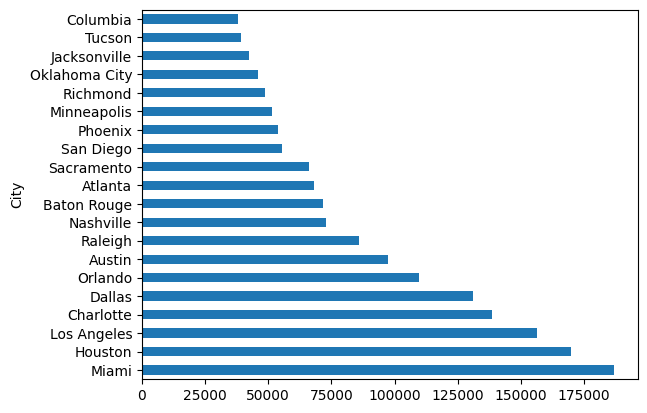

In [17]:
cities_by_accident[:20].plot(kind='barh')

In [18]:
import seaborn as sns
sns.set_style('darkgrid')

<Axes: xlabel='count', ylabel='Count'>

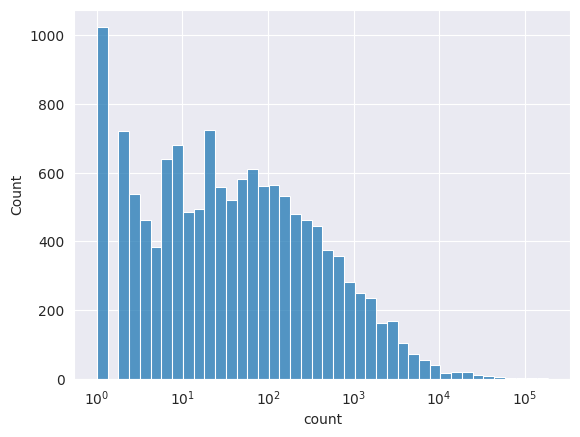

In [19]:
sns.histplot(cities_by_accident, log_scale=True)

In [20]:
cities_by_accident[cities_by_accident == 1]

,count
City,
American Fork-Pleasant Grove,1
Waldoboro,1
Kinsley,1
Killona,1
Jeanerette,1
...,...
Rapid River,1
Cat Spring,1
Glenwood City,1


In [21]:
high_accident_cities = cities_by_accident[cities_by_accident >= 1000]
low_accident_cities = cities_by_accident[cities_by_accident < 1000]

In [22]:
len(high_accident_cities)/ len(low_accident_cities)

0.09775280898876404

In [23]:
'New York' in df.City

False

In [24]:
'NY' in df.State

False

<Axes: xlabel='count', ylabel='Count'>

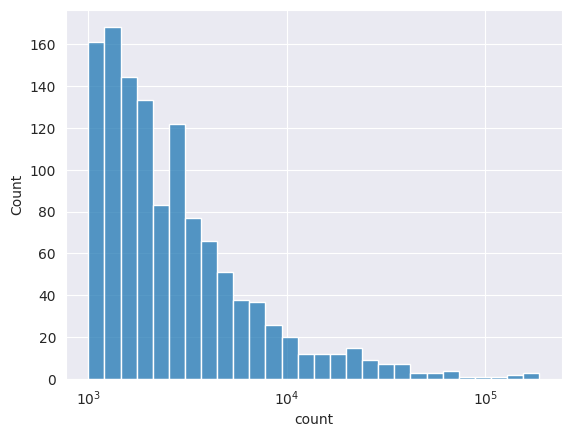

In [25]:
sns.histplot(high_accident_cities, log_scale=True)

/tmp/ipython-input-469555131.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(low_accident_cities)


<Axes: xlabel='count', ylabel='Density'>

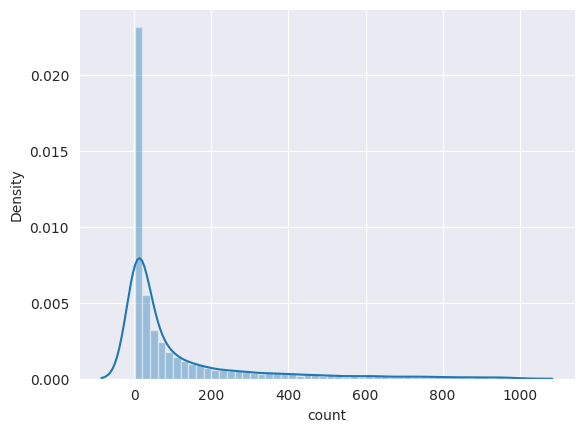

In [26]:
sns.distplot(low_accident_cities)

###Start Time


In [27]:
df.Start_Time

,Start_Time
0,2016-02-08 05:46:00
1,2016-02-08 06:07:59
2,2016-02-08 06:49:27
3,2016-02-08 07:23:34
4,2016-02-08 07:39:07
...,...
7728389,2019-08-23 18:03:25
7728390,2019-08-23 19:11:30
7728391,2019-08-23 19:00:21
7728392,2019-08-23 19:00:21


In [30]:
df.Start_Time = pd.to_datetime(df.Start_Time, format = 'mixed')
df.Start_Time[0]

Timestamp('2016-02-08 05:46:00')

/tmp/ipython-input-1705024698.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Start_Time.dt.hour, bins = 24, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

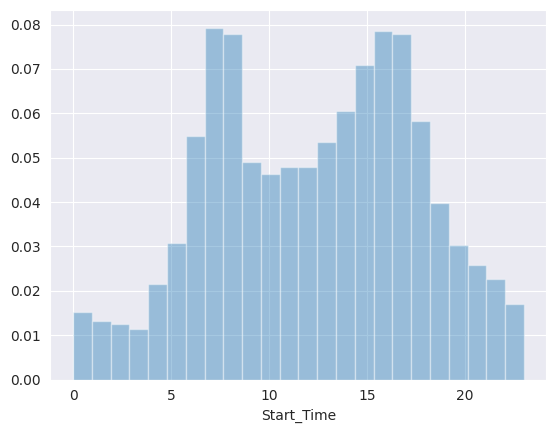

In [36]:
sns.distplot(df.Start_Time.dt.hour, bins = 24, kde=False, norm_hist=True)

- A high percentage of accidents occur between 6 am to 10 am (Probably people in a hurry to get to work)
- Next highest percentage of accidents occur between 3 pm to 6 pm

/tmp/ipython-input-1106379764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Start_Time.dt.dayofweek, bins = 7, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

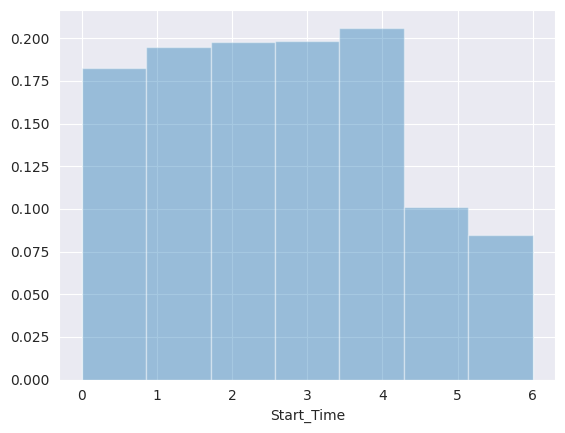

In [37]:
sns.distplot(df.Start_Time.dt.dayofweek, bins = 7, kde=False, norm_hist=True)

Is the distribution of accidents by hour the same on weekends as weekdays?

/tmp/ipython-input-1369835080.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sundays_start_time.dt.hour, bins = 24, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

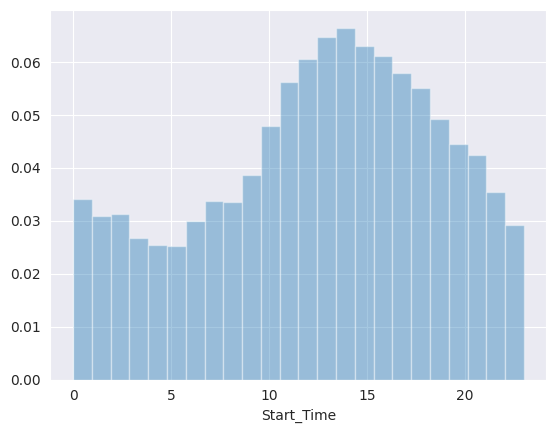

In [39]:
sundays_start_time = df.Start_Time[df.Start_Time.dt.dayofweek == 6]
sns.distplot(sundays_start_time.dt.hour, bins = 24, kde=False, norm_hist=True)

/tmp/ipython-input-2445510527.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mondays_start_time.dt.hour, bins = 24, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

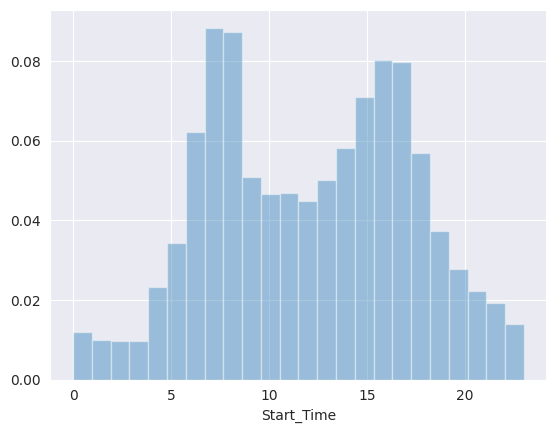

In [40]:
mondays_start_time = df.Start_Time[df.Start_Time.dt.dayofweek == 0]
sns.distplot(mondays_start_time.dt.hour, bins = 24, kde=False, norm_hist=True)

On Sundays, the peak occurs between 10 am and 3 pm unlike weekdays

/tmp/ipython-input-47457737.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

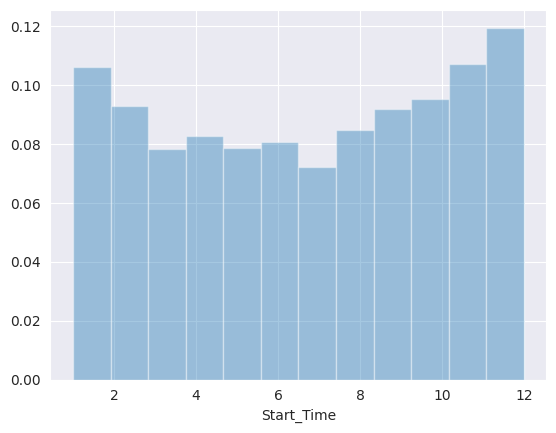

In [42]:
sns.distplot(df.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

More car accidents occur during the winter season ?

- Much Data is missing for certain years leading to the unusual trend.
- there seems to be some issue with the Source 1 data

/tmp/ipython-input-102503487.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2019.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

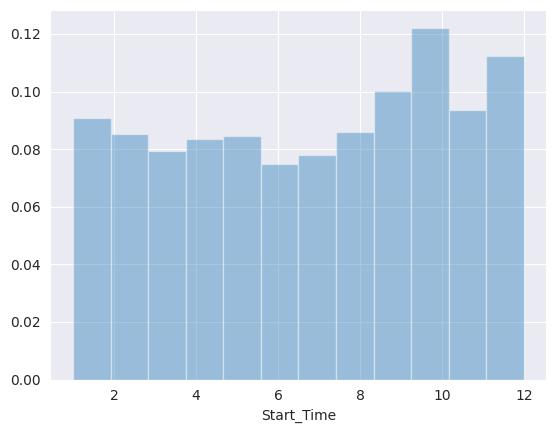

In [45]:
df_2019 = df[df.Start_Time.dt.year == 2019]
df_2020 = df[df.Start_Time.dt.year == 2020]
sns.distplot(df_2019.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-3673311340.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2020.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

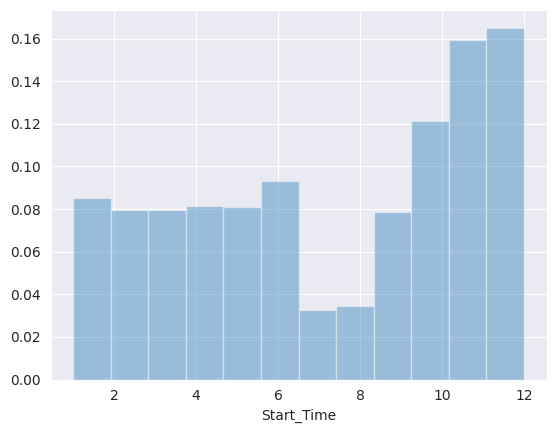

In [46]:
sns.distplot(df_2020.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-3222069987.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2016.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

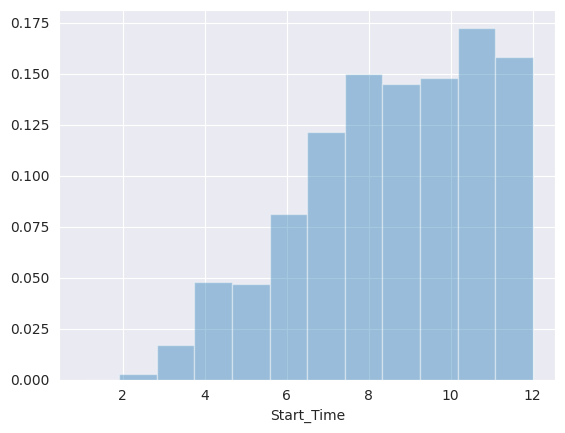

In [47]:
df_2016 = df[df.Start_Time.dt.year == 2016]
sns.distplot(df_2016.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-4288695815.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2017.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

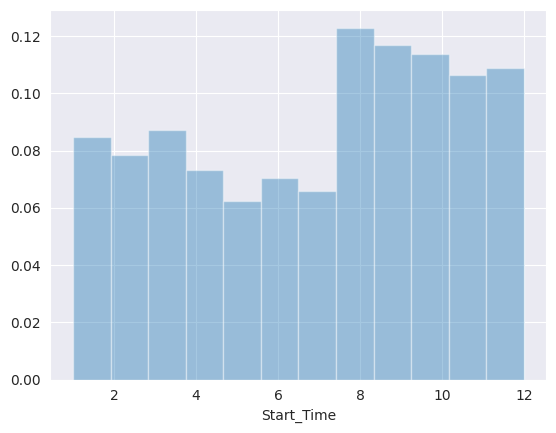

In [48]:
df_2017 = df[df.Start_Time.dt.year == 2017]
sns.distplot(df_2017.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-566068703.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2018.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

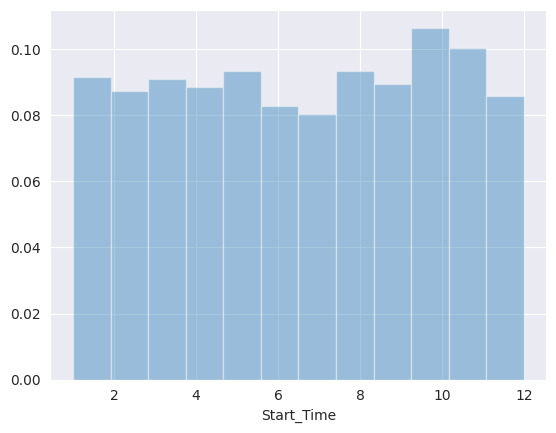

In [49]:
df_2018 = df[df.Start_Time.dt.year == 2018]
sns.distplot(df_2018.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-325736540.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2021.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

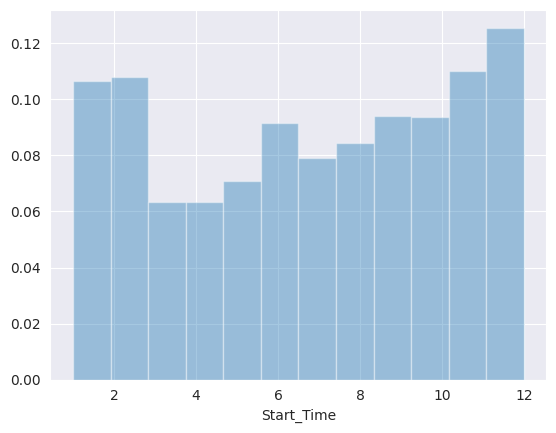

In [50]:
df_2021 = df[df.Start_Time.dt.year == 2021]
sns.distplot(df_2021.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-1076052647.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2022.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

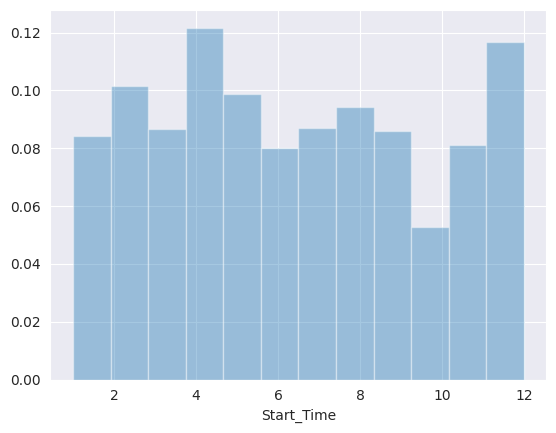

In [51]:
df_2022 = df[df.Start_Time.dt.year == 2022]
sns.distplot(df_2022.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-3957957598.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2023.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

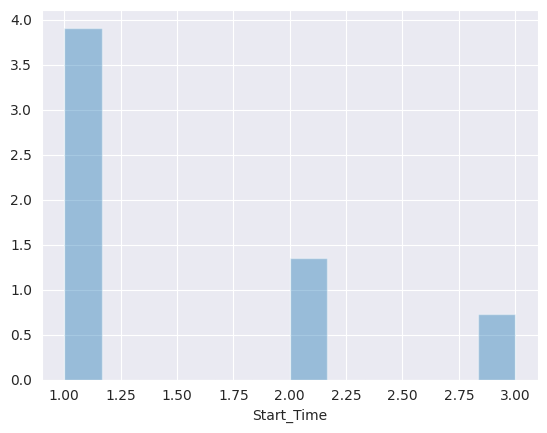

In [52]:
df_2023 = df[df.Start_Time.dt.year == 2023]
sns.distplot(df_2023.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-1427665207.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2019_Source1.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

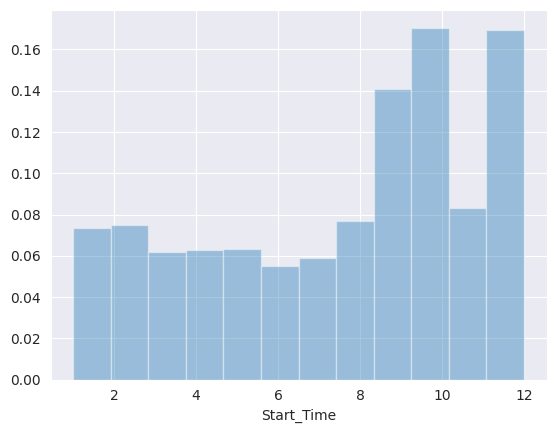

In [56]:
df_2019_Source1 = df_2019[df_2019.Source == 'Source1']
sns.distplot(df_2019_Source1.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

/tmp/ipython-input-3181922093.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_2019_Source2.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)


<Axes: xlabel='Start_Time'>

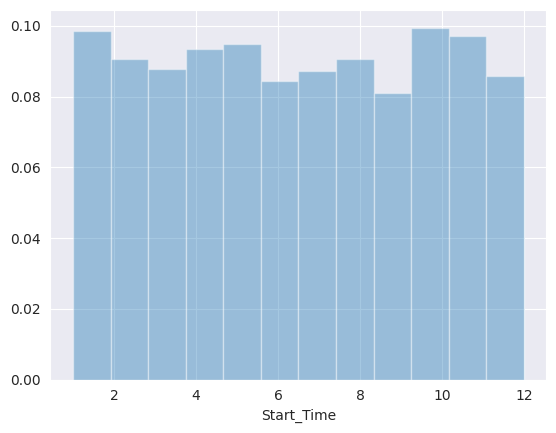

In [57]:
df_2019_Source2 = df_2019[df_2019.Source == 'Source2']
sns.distplot(df_2019_Source2.Start_Time.dt.month, bins = 12, kde=False, norm_hist=True)

<Axes: ylabel='count'>

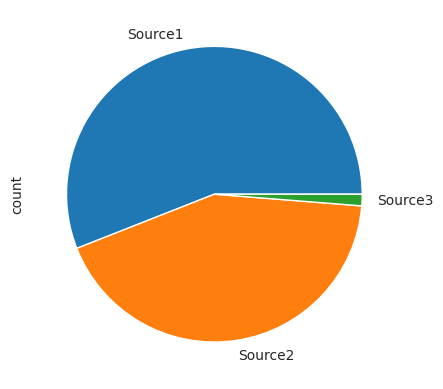

In [53]:
df.Source.value_counts().plot(kind = 'pie')

Consider excluding Source 1 data, seems to have some issues (also has majority of the data, so might lead to a problem)

###Start Latitude and Longitude

In [58]:
df.Start_Lat

,Start_Lat
0,39.865147
1,39.928059
2,39.063148
3,39.747753
4,39.627781
...,...
7728389,34.002480
7728390,32.766960
7728391,33.775450
7728392,33.992460


In [59]:
df.Start_Lng

,Start_Lng
0,-84.058723
1,-82.831184
2,-84.032608
3,-84.205582
4,-84.188354
...,...
7728389,-117.379360
7728390,-117.148060
7728391,-117.847790
7728392,-118.403020


<Axes: xlabel='Start_Lng', ylabel='Start_Lat'>

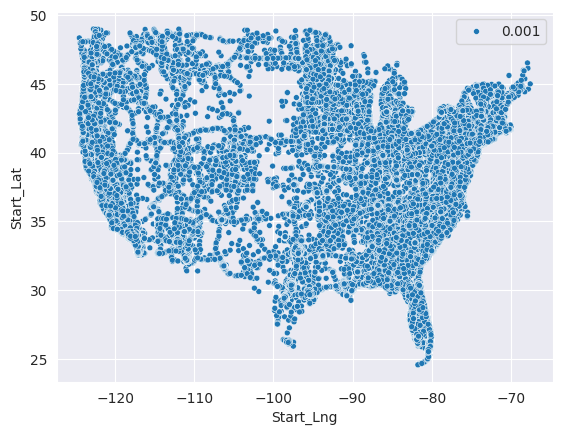

In [62]:
sample_df = df.sample(int(0.1 * len(df)))
sns.scatterplot(data = sample_df, x = 'Start_Lng', y = 'Start_Lat', size = 0.001)

In [64]:
!pip install folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.4/113.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.4/90.4 kB 5.9 MB/s eta 0:00:00


In [90]:
import folium
from folium.plugins import HeatMap

In [91]:
lat, lon = df.Start_Lat[0], df.Start_Lng[0]
lat, lon

(np.float64(39.865147), np.float64(-84.058723))

In [102]:
sample_df = df.sample(int(0.001 * len(df)))
lat_lon_pairs = list(zip(list(sample_df.Start_Lat), list(sample_df.Start_Lng)))

In [103]:
map = folium.Map()
HeatMap(lat_lon_pairs).add_to(map)
map

## Ask and answer questions

1. Are there more accidents in warmer or colder area ?
2. Which 5 states have the highest number of accidents ? How about per capita ?
3. Does New York show up in the data ? If yes, why is the count lower if this is the most populated city ?
4. Among the top 100 cities in number of accidents, which states do they belong to most frequently?
5. What time of the day are accidents most frequent in?
6. Which days of the week have the most accidents?
7. Which months have the most accidents?
8. What is the trend of accidents year over year (decreasing / increasing)
9. When is accidents per unit traffic highest ?

## Summary and Conclusion

Insights:
- No data for New York
- The number of accidents per city decreases exponentially
- Less than 5% of cities have more than 1000 yearly accidents
- Over 1000 cities have reported just one accident (need to investigate)